## Import Necessary Module

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense, Flatten, Reshape, Conv2DTranspose, GlobalAveragePooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomContrast

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
import gc

## Load Cifar10 Data

In [8]:
(trainX, trainY), (testX, testY) = cifar10.load_data()

trainX = trainX.astype('float32') / 255.
testX = testX.astype('float32') / 255.

trainY_flat = trainY.flatten()
testY_flat = testY.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print('trainX shape:', trainX.shape)
print(trainX.shape[0], 'train samples')
print(testX.shape[0], 'test samples')

trainX shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


# 3. Training a denoising autoencoder for CIFAR10 dataset.

### Adding Noise to Images

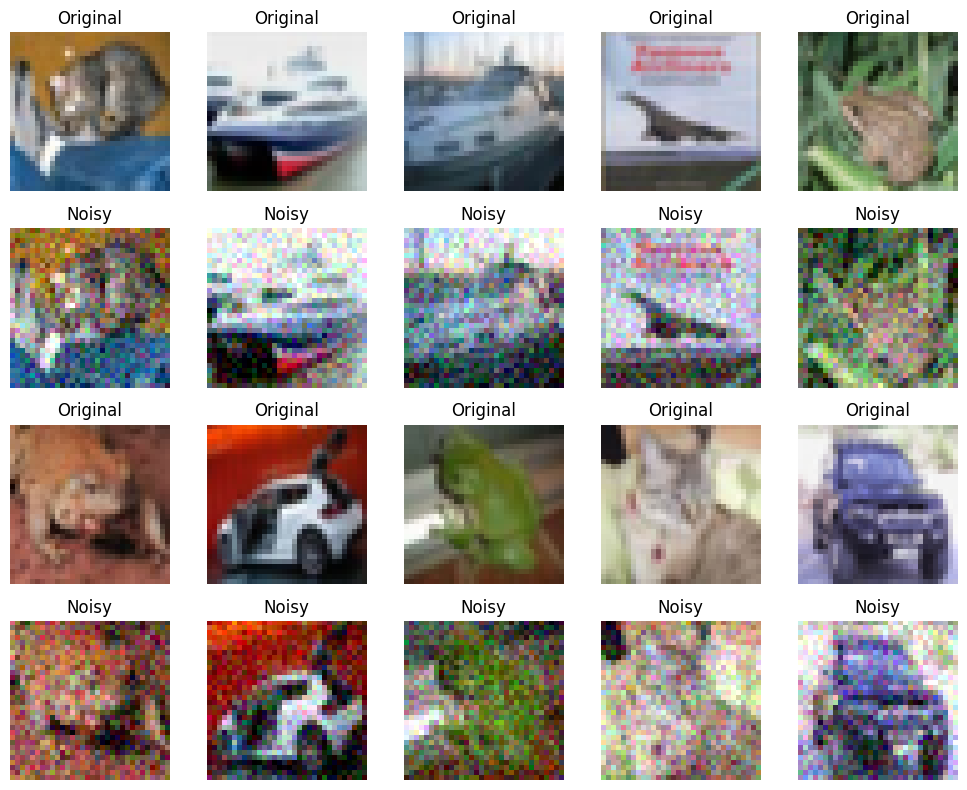

In [9]:
noise_factor = 0.1

trainX_noisy = trainX + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=trainX.shape)
testX_noisy = testX + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=testX.shape)

trainX_noisy = np.clip(trainX_noisy, 0., 1.)
testX_noisy = np.clip(testX_noisy, 0., 1.)

n = 10
cols = 5
rows = 4

plt.figure(figsize=(10, 8))

for i in range(n):
    row_offset = 0 if i < 5 else 2

    # Original image
    ax = plt.subplot(rows, cols, (i % 5) + 1 + row_offset * cols)
    plt.imshow(testX[i])
    plt.title("Original")
    ax.axis('off')

    # Noisy image
    ax = plt.subplot(rows, cols, (i % 5) + 1 + (row_offset + 1) * cols)
    plt.imshow(testX_noisy[i])
    plt.title("Noisy")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Building the Denoising Autoencoder Model

In [10]:
input_img = Input(shape=(32, 32, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x) # 16x16
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x) # 8x8
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x) # 4x4 - This is the bottleneck

x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x) # 8x8
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x) # 16x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x) # 32x32
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

denoising_autoencoder = Model(input_img, decoded)
denoising_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,507 (584.01 KB)

 Trainable params: 149,507 (584.01 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train the denoising autoencoder

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0258 - val_loss: 0.0114
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0111 - val_loss: 0.0097
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0097 - val_loss: 0.0088
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0088 - val_loss: 0.0086
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0077 - val_loss: 0.0071
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0073 - val_loss: 0.0071
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0069 - val_loss: 0.0066
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0067 - val_loss: 0.0066
Epoch 10/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 11/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0063 - val_loss: 0.0067
Epoch 12/50
391/391 ━━━━━━━━━━━━━━━━━━━━

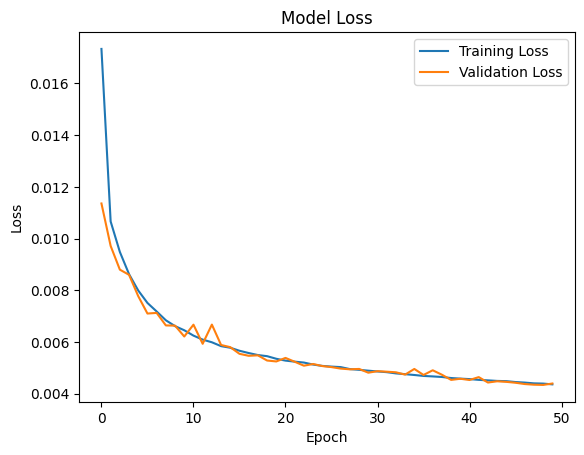

In [11]:
denoising_autoencoder.compile(optimizer='adam', loss='mean_squared_error')

history = denoising_autoencoder.fit(
    trainX_noisy, trainX,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(testX_noisy, testX)
)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Visualize the denoised images

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


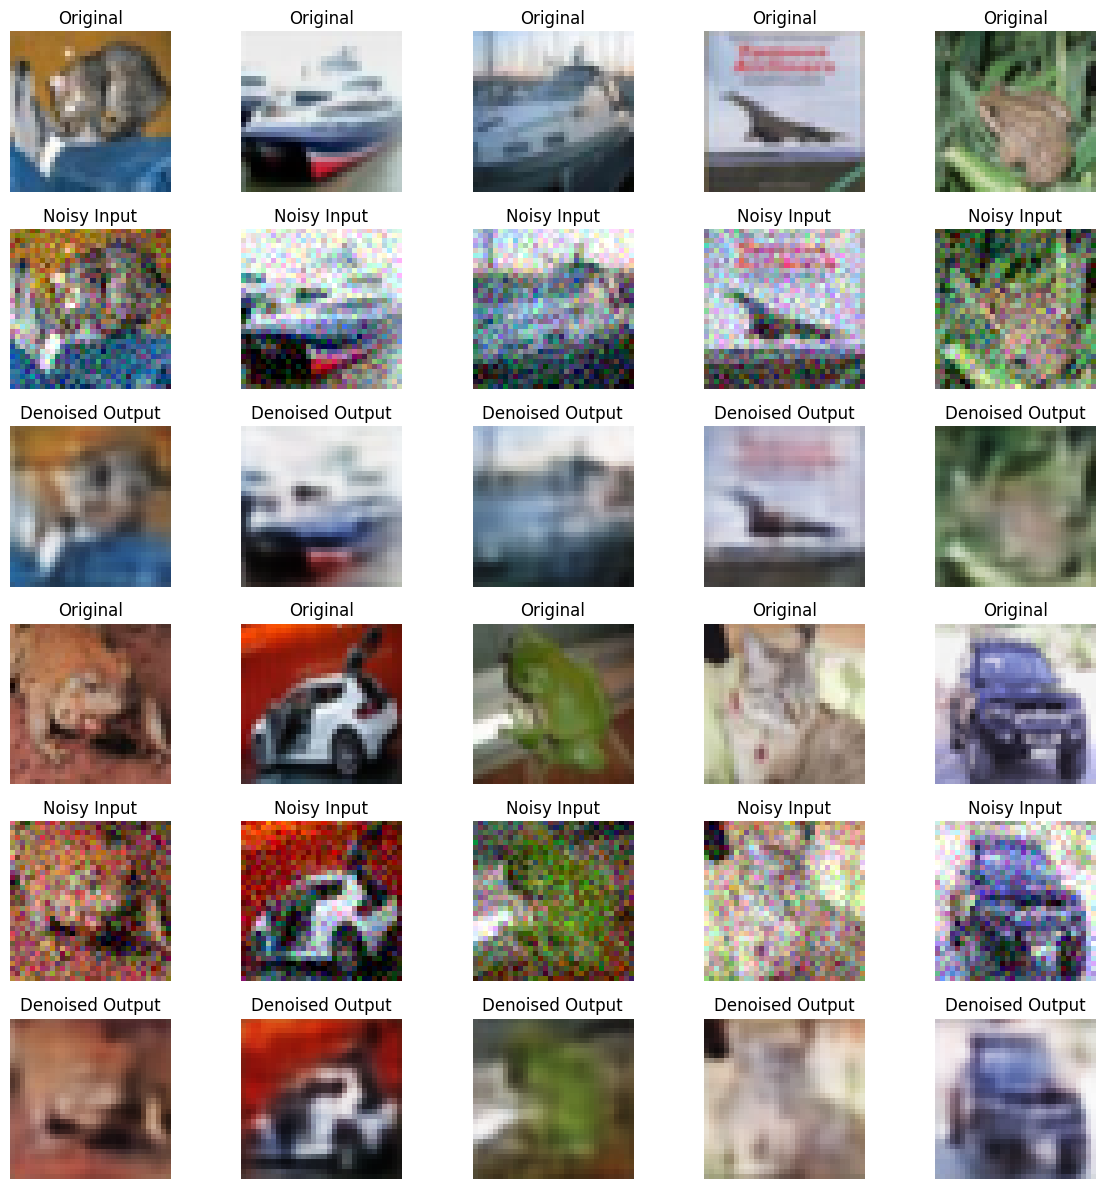

In [30]:
denoised_images = denoising_autoencoder.predict(testX_noisy)
n = 10
cols = 5
rows = 6

plt.figure(figsize=(12, 12))

for i in range(n):
    col = i % 5
    group = 0 if i < 5 else 1

    # Row indices
    orig_row = group * 3
    noisy_row = orig_row + 1
    denoise_row = orig_row + 2

    # Original
    ax = plt.subplot(rows, cols, col + 1 + orig_row * cols)
    plt.imshow(testX[i])
    plt.title("Original")
    ax.axis('off')

    # Noisy Input
    ax = plt.subplot(rows, cols, col + 1 + noisy_row * cols)
    plt.imshow(testX_noisy[i])
    plt.title("Noisy Input")
    ax.axis('off')

    # Denoised Output
    ax = plt.subplot(rows, cols, col + 1 + denoise_row * cols)
    plt.imshow(denoised_images[i])
    plt.title("Denoised Output")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Training a CNN based CIFAR-10 classifier without any single-image data augmentation techniques.

### Build the VGG-16 based classifier

In [13]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

vgg_base.trainable = True
print(f"Number of layers in the base model: {len(vgg_base.layers)}")
print("All layers in the VGG16 base are now trainable.")

inputs = Input(shape=(32, 32, 3))
x = vgg_base(inputs, training=True)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
outputs = Dense(10)(x)

classifier_model = Model(inputs, outputs)

classifier_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers in the base model: 19
All layers in the VGG16 base are now trainable.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 14,848,586 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

In [14]:
classifier_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


## Set Necessary Parameter

In [15]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 40
IMAGE_SIZE = (32, 32, 3)
NUM_CLASSES = 10

## Data Preparation (Train / Validation / Test Split)

In [16]:
(tarinX_full, trainY_full), (testX, testY) = cifar10.load_data()

tarinX_full = tarinX_full.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0

trainX, val_X, trainY, val_Y = train_test_split(
    tarinX_full, trainY_full, test_size=0.2, random_state=42
)

trainY = trainY.flatten()
val_Y = val_Y.flatten()
testY = testY.flatten()

print(f"Training set shape:   {trainX.shape}")
print(f"Validation set shape: {val_X.shape}")
print(f"Test set shape:       {testX.shape}")

Training set shape:   (40000, 32, 32, 3)
Validation set shape: (10000, 32, 32, 3)
Test set shape:       (10000, 32, 32, 3)


## Create data Pipelines

In [17]:
data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1),
    ],
    name="data_augmentation",
)

train_ds_aug = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds_aug = train_ds_aug.shuffle(buffer_size=len(trainX))
train_ds_aug = train_ds_aug.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds_aug = train_ds_aug.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds_no_aug = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds_no_aug = train_ds_no_aug.shuffle(buffer_size=len(trainX))
train_ds_no_aug = train_ds_no_aug.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_Y)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((testX, testY)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Data pipelines created.")

Data pipelines created.


##  Visualize Augmented Image

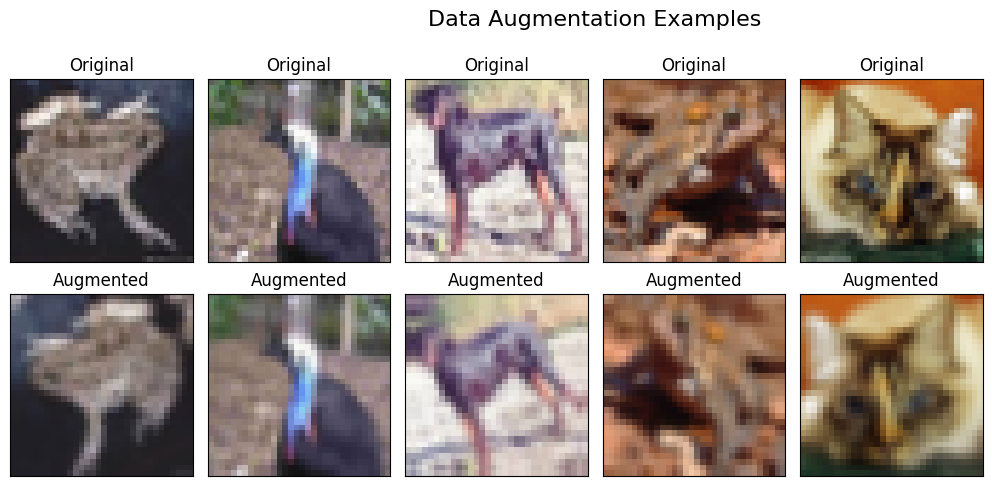

In [25]:

sample_images = trainX[:5]
augmented_images_list = []
for image in sample_images:
    augmented_image = data_augmentation(image)
    augmented_images_list.append(augmented_image)

augmented_images = np.array(augmented_images_list)

plt.figure(figsize=(12, 5))
plt.suptitle("Data Augmentation Examples", fontsize=16)

for i in range(5):
    ax = plt.subplot(2, 6, i + 1)
    plt.imshow(sample_images[i])
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 6, i + 1 + 6)
    plt.imshow(np.clip(augmented_images[i], 0, 1))
    plt.title("Augmented")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Model Building Function

In [19]:
def build_classifier_model():

    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    vgg_base.trainable = True

    inputs = Input(shape=(32, 32, 3))
    x = vgg_base(inputs, training=True)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    outputs = Dense(10)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

print("Model builder function defined.")

Model builder function defined.


## Model Train without Augmentation

In [20]:
print("--- Training Model WITHOUT Data Augmentation ---")
model_no_aug = build_classifier_model()

history_no_aug = model_no_aug.fit(
    train_ds_no_aug,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1
)

--- Training Model WITHOUT Data Augmentation ---
Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - accuracy: 0.4875 - loss: 1.4506 - val_accuracy: 0.7329 - val_loss: 0.7690
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7515 - loss: 0.7159 - val_accuracy: 0.7744 - val_loss: 0.6647
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.8006 - loss: 0.5748 - val_accuracy: 0.7798 - val_loss: 0.6324
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.8265 - loss: 0.4946 - val_accuracy: 0.8081 - val_loss: 0.5657
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8521 - loss: 0.4244 - val_accuracy: 0.8158 - val_loss: 0.5445
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8736 - loss: 0.3631 - val_accuracy: 0.8123 - val_loss: 0.5746
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.8872 - loss: 0.3216 - val_accuracy: 0.8175 - val_loss: 0.5595
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3

## 5. Training a CNN based CIFAR-10 classifier with a single/multiple single-image data augmentation techniques.

### Train the model with Augmentation

In [21]:
print("\n--- Training Model WITH Data Augmentation ---")
model_with_aug = build_classifier_model()

history_with_aug = model_with_aug.fit(
    train_ds_aug,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1
)


--- Training Model WITH Data Augmentation ---
Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.4418 - loss: 1.5779 - val_accuracy: 0.6697 - val_loss: 0.9455
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accuracy: 0.6784 - loss: 0.9193 - val_accuracy: 0.7151 - val_loss: 0.8172
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.7187 - loss: 0.7984 - val_accuracy: 0.7538 - val_loss: 0.7146
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.7416 - loss: 0.7419 - val_accuracy: 0.7728 - val_loss: 0.6563
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 93ms/step - accuracy: 0.7595 - loss: 0.6831 - val_accuracy: 0.7767 - val_loss: 0.6468
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.7758 - loss: 0.6455 - val_accuracy: 0.7867 - val_loss: 0.6279
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7873 - loss: 0.6083 - val_accuracy: 0.7990 - val_loss: 0.5849
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s

### Final Evaluation and Visualization

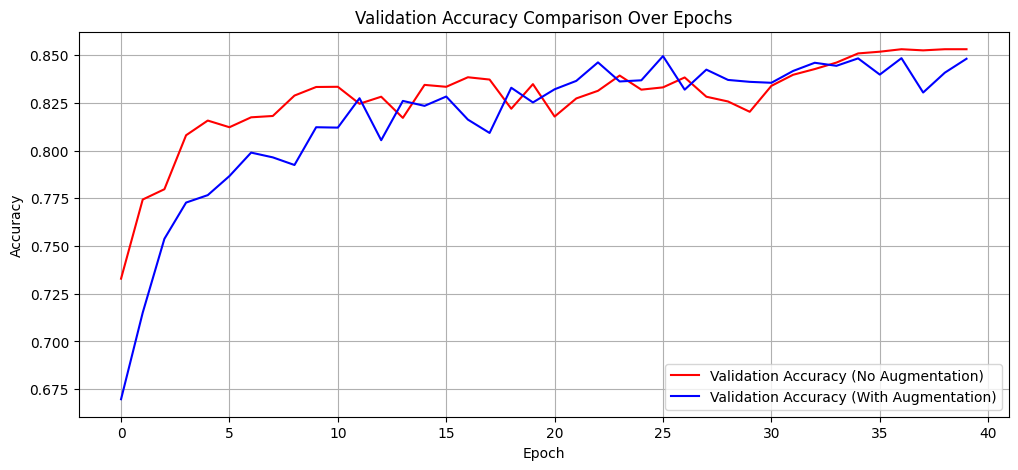


Evaluating final performance on the held-out test set...


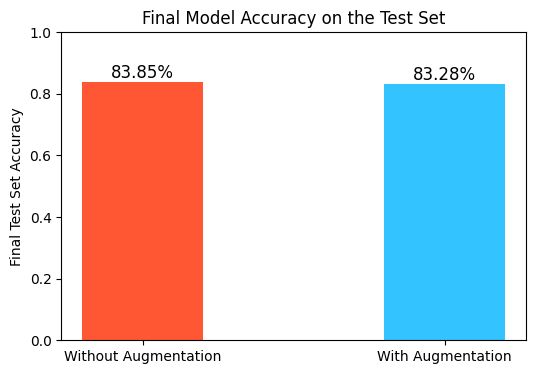

In [28]:
val_acc_no_aug = history_no_aug.history['val_accuracy']
val_acc_with_aug = history_with_aug.history['val_accuracy']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.plot(epochs_range, val_acc_no_aug, label='Validation Accuracy (No Augmentation)', color='red')
plt.plot(epochs_range, val_acc_with_aug, label='Validation Accuracy (With Augmentation)', color='blue')
plt.title('Validation Accuracy Comparison Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("\nEvaluating final performance on the held-out test set...")
loss_no_aug, acc_no_aug = model_no_aug.evaluate(test_ds, verbose=0)
loss_with_aug, acc_with_aug = model_with_aug.evaluate(test_ds, verbose=0)

labels = ['Without Augmentation', 'With Augmentation']
test_accuracies = [acc_no_aug, acc_with_aug]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, test_accuracies, color=['#FF5733', '#33C4FF'], width=0.4)
plt.ylabel('Final Test Set Accuracy')
plt.title('Final Model Accuracy on the Test Set')
plt.ylim([0, 1.0])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval*100:.2f}%', va='bottom', ha='center', fontsize=12)

plt.show()

### Build model with additional argument 'optimizer' to handel learning rate schedule

In [23]:
def build_classifier_model(optimizer):

    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    vgg_base.trainable = True

    inputs = Input(shape=(32, 32, 3))
    x = vgg_base(inputs, training=True)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    outputs = Dense(10)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

print("Model builder function updated.")

Model builder function updated.


### Train the model with learning rate schedule

In [24]:
print("\n--- Training Model WITH Augmentation and LR Scheduling ---")

initial_learning_rate = 0.0001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True)

optimizer_scheduled = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model_aug_scheduled = build_classifier_model(optimizer_scheduled)

train_ds_aug = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds_aug = train_ds_aug.shuffle(len(trainX)).map(
    lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_Y)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((testX, testY)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

history_aug_scheduled = model_aug_scheduled.fit(
    train_ds_aug,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1
)

print("\nEvaluating scheduled model on test set...")
_, acc_aug_scheduled = model_aug_scheduled.evaluate(test_ds, verbose=0)
print(f"Final Test Accuracy (With Augmentation + LR Schedule): {acc_aug_scheduled*100:.2f}%")


--- Training Model WITH Augmentation and LR Scheduling ---
Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.4947 - loss: 1.4005 - val_accuracy: 0.7389 - val_loss: 0.7777
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 91ms/step - accuracy: 0.7273 - loss: 0.7965 - val_accuracy: 0.7745 - val_loss: 0.6645
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.7739 - loss: 0.6508 - val_accuracy: 0.8217 - val_loss: 0.5338
Epoch 4/40
236/625 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.8001 - loss: 0.5865

KeyboardInterrupt: 

## Plot the Result

In [ ]:
acc_no_aug = 0.8372

acc_with_aug_fixed_lr = 0.8196

acc_with_aug_scheduled = acc_aug_scheduled

labels = [
    'Without Augmentation',
    'With Augmentation\n(Fixed Slow LR)',
    'With Augmentation\n(LR Schedule)'
]
test_accuracies = [acc_no_aug, acc_with_aug_fixed_lr, acc_with_aug_scheduled]
colors = ['#2196F3', '#E91E63', '#9C27B0']

plt.figure(figsize=(12, 7))
bars = plt.bar(labels, test_accuracies, color=colors)

plt.ylabel('Final Test Set Accuracy')
plt.title('Final Model Accuracy Comparison')
plt.ylim([0, 1.0])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval*100:.2f}%', va='bottom', ha='center', fontsize=12)

plt.show()